# **APS Failure at Scania Trucks**

**Note:** This is a pretty rough first look, but can help decide which is easiest to work w/

**Link:** https://archive.ics.uci.edu/dataset/421/aps+failure+at+scania+trucks

This one concerns air brake failure using real world data, it is an okay dataset, there is a lot of features missing a significant amount of data
is the main concern, more complicated on addressing that (i.e. complicated imputing, or more than likely just dropping a lot of rows/features). Lots of features are also highly correlated, can be a headache, but this dataset is good in terms of data processing requirements.

This is a multivariable dataset based on real world data, classification task

To be frank, this one would be more time consuming but good to learn. Prolly more work than reasonably necessary. It does have an insteresting "cost metric of mis classification". Could be an interesting presentation point, albeit higher workload.

---

In [17]:
# Global imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 150)
sns.set_style("whitegrid")

In [18]:
# This is the only thing that really needs to change when looking from dataset to dataset, run everything else that follows as normal

DATA_PATH = "aps_failure_training_set.csv"
SKIPROWS = 20
NA_VALUES = "na"
TARGET_COL = "class"
TOP_K = 30

In [19]:
# Load the data

df = pd.read_csv(DATA_PATH, skiprows=SKIPROWS, na_values=NA_VALUES)
print(f"Shape: {df.shape}")
df.head(10)

Shape: (60000, 171)


,class,aa_000,ab_000,ac_000,ad_000,ae_000,af_000,ag_000,ag_001,ag_002,ag_003,ag_004,ag_005,ag_006,ag_007,ag_008,ag_009,ah_000,ai_000,aj_000,ak_000,al_000,am_0,an_000,ao_000,...,dq_000,dr_000,ds_000,dt_000,du_000,dv_000,dx_000,dy_000,dz_000,ea_000,eb_000,ec_00,ed_000,ee_000,ee_001,ee_002,ee_003,ee_004,ee_005,ee_006,ee_007,ee_008,ee_009,ef_000,eg_000
0,neg,76698,NaN,2.130706e+09,280.0,0.0,0.0,0.0,0.0,0.0,0.0,37250.0,1432864.0,3664156.0,1007684.0,25896.0,0.0,2551696.0,0.0,0.0,0.0,0.0,0.0,4933296.0,3655166.0,...,0.0,0.0,202710.0,37928.0,14745580.0,1876644.0,0.0,0.0,0.0,0.0,2801180.0,2445.80,2712.0,965866.0,1706908.0,1240520.0,493384.0,721044.0,469792.0,339156.0,157956.0,73224.0,0.0,0.0,0.0
1,neg,33058,NaN,0.000000e+00,NaN,0.0,0.0,0.0,0.0,0.0,0.0,18254.0,653294.0,1720800.0,516724.0,31642.0,0.0,1393352.0,0.0,68.0,0.0,0.0,0.0,2560898.0,2127150.0,...,0.0,0.0,103330.0,16254.0,4510080.0,868538.0,0.0,0.0,0.0,0.0,3477820.0,2211.76,2334.0,664504.0,824154.0,421400.0,178064.0,293306.0,245416.0,133654.0,81140.0,97576.0,1500.0,0.0,0.0
2,neg,41040,NaN,2.280000e+02,100.0,0.0,0.0,0.0,0.0,0.0,0.0,1648.0,370592.0,1883374.0,292936.0,12016.0,0.0,1234132.0,0.0,0.0,0.0,0.0,0.0,2371990.0,2173634.0,...,0.0,0.0,65772.0,10534.0,300240.0,48028.0,0.0,0.0,0.0,0.0,1040120.0,1018.64,1020.0,262032.0,453378.0,277378.0,159812.0,423992.0,409564.0,320746.0,158022.0,95128.0,514.0,0.0,0.0
3,neg,12,0.0,7.000000e+01,66.0,0.0,10.0,0.0,0.0,0.0,318.0,2212.0,3232.0,1872.0,0.0,0.0,0.0,2668.0,0.0,0.0,0.0,642.0,3894.0,10184.0,7554.0,...,2014.0,370.0,48.0,18.0,15740.0,1822.0,20174.0,44.0,0.0,0.0,0.0,1.08,54.0,5670.0,1566.0,240.0,46.0,58.0,44.0,10.0,0.0,0.0,0.0,4.0,32.0
4,neg,60874,NaN,1.368000e+03,458.0,0.0,0.0,0.0,0.0,0.0,0.0,43752.0,1966618.0,1800340.0,131646.0,4588.0,0.0,1974038.0,0.0,226.0,0.0,0.0,0.0,3230626.0,2618878.0,...,0.0,0.0,149474.0,35154.0,457040.0,80482.0,98334.0,27588.0,0.0,0.0,21173050.0,1116.06,1176.0,404740.0,904230.0,622012.0,229790.0,405298.0,347188.0,286954.0,311560.0,433954.0,1218.0,0.0,0.0
5,neg,38312,NaN,2.130706e+09,218.0,0.0,0.0,0.0,0.0,0.0,0.0,9128.0,701702.0,1462836.0,449716.0,39000.0,660.0,1087760.0,0.0,0.0,0.0,0.0,0.0,2283060.0,1892752.0,...,0.0,0.0,52748.0,12092.0,10244700.0,1126020.0,0.0,0.0,0.0,0.0,0.0,1013.14,1100.0,301078.0,481542.0,388574.0,288278.0,900430.0,300412.0,1534.0,338.0,856.0,0.0,0.0,0.0
6,neg,14,0.0,6.000000e+00,NaN,0.0,0.0,0.0,0.0,0.0,0.0,1202.0,3766.0,1150.0,0.0,0.0,0.0,2094.0,0.0,0.0,0.0,0.0,0.0,12460.0,11044.0,...,0.0,0.0,62.0,24.0,4200.0,1184.0,0.0,0.0,0.0,0.0,0.0,374.44,62.0,4252.0,1562.0,168.0,48.0,60.0,28.0,0.0,0.0,0.0,0.0,0.0,0.0
7,neg,102960,NaN,2.130706e+09,116.0,0.0,0.0,0.0,0.0,0.0,0.0,2130.0,142462.0,4227340.0,1674278.0,59718.0,876.0,2738458.0,0.0,0.0,0.0,0.0,0.0,5586558.0,4916376.0,...,0.0,0.0,133502.0,26976.0,14438160.0,1487036.0,0.0,0.0,0.0,0.0,3537310.0,2018.08,2168.0,543294.0,907360.0,715518.0,384948.0,915978.0,1052166.0,1108672.0,341532.0,129504.0,7832.0,0.0,0.0
8,neg,78696,NaN,0.000000e+00,NaN,0.0,0.0,0.0,0.0,0.0,0.0,458.0,440704.0,4398806.0,2179182.0,144418.0,808.0,3209768.0,0.0,80.0,0.0,0.0,0.0,6289144.0,5590784.0,...,0.0,0.0,270482.0,49762.0,15642140.0,1860094.0,0.0,0.0,0.0,0.0,400610.0,2668.64,2870.0,1875574.0,1759758.0,699290.0,362510.0,1190028.0,1012704.0,160090.0,63216.0,41202.0,4.0,0.0,0.0
9,pos,153204,0.0,1.820000e+02,NaN,0.0,0.0,0.0,0.0,0.0,11804.0,684444.0,326536.0,31586.0,0.0,0.0,0.0,2658638.0,14346.0,0.0,0.0,29384.0,46356.0,5566182.0,4426834.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.90,166.0,512878.0,293880.0,129862.0,26872.0,34044.0,22472.0,34362.0,0.0,0.0,0.0,0.0,0.0


In [20]:
# Basic info

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Columns: 171 entries, class to eg_000
dtypes: float64(169), int64(1), str(1)
memory usage: 78.3 MB


In [21]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
aa_000,60000.0,5.933650e+04,1.454301e+05,0.0,834.0,30776.0,48668.0,2.746564e+06
ab_000,13671.0,7.131885e-01,3.478962e+00,0.0,0.0,0.0,0.0,2.040000e+02
ac_000,56665.0,3.560143e+08,7.948749e+08,0.0,16.0,152.0,964.0,2.130707e+09
ad_000,45139.0,1.906206e+05,4.040441e+07,0.0,24.0,126.0,430.0,8.584298e+09
ae_000,57500.0,6.819130e+00,1.615434e+02,0.0,0.0,0.0,0.0,2.105000e+04
...,...,...,...,...,...,...,...,...
ee_007,59329.0,3.462714e+05,1.728056e+06,0.0,110.0,41098.0,167814.0,1.195801e+08
ee_008,59329.0,1.387300e+05,4.495100e+05,0.0,0.0,3812.0,139724.0,1.926740e+07
ee_009,59329.0,8.388915e+03,4.747043e+04,0.0,0.0,0.0,2028.0,3.810078e+06
ef_000,57276.0,9.057895e-02,4.368855e+00,0.0,0.0,0.0,0.0,4.820000e+02


In [22]:
if TARGET_COL in df.columns:
    print(df[TARGET_COL].value_counts())
    print()
    print((df[TARGET_COL].value_counts(normalize=True) * 100).round(2).astype(str) + " %")
else:
    print(f"Column '{TARGET_COL}' not found — update TARGET_COL in the config cell.")

class
neg    59000
pos     1000
Name: count, dtype: int64

class
neg    98.33 %
pos     1.67 %
Name: proportion, dtype: str


In [23]:
# Null value check

null_counts = df.isnull().sum()
null_pct = (null_counts / len(df) * 100).round(2)
 
null_summary = (
    pd.DataFrame({"n_missing": null_counts, "pct_missing": null_pct})
    .query("n_missing > 0")
    .sort_values("pct_missing", ascending=False)
)
 
print(f"Columns with at least one missing value: {len(null_summary)} / {df.shape[1]}")
null_summary.head(30)

Columns with at least one missing value: 169 / 171


,n_missing,pct_missing
br_000,49264,82.11
bq_000,48722,81.20
bp_000,47740,79.57
bo_000,46333,77.22
cr_000,46329,77.22
ab_000,46329,77.22
bn_000,44009,73.35
bm_000,39549,65.92
bl_000,27277,45.46
bk_000,23034,38.39


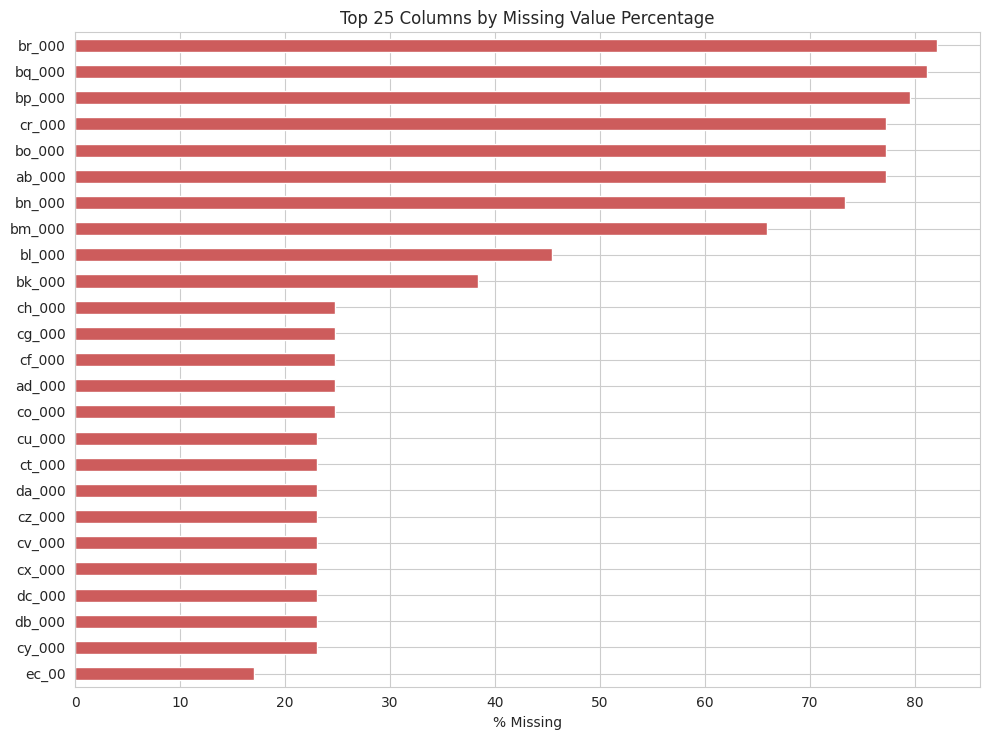

In [24]:
top_n_missing = min(25, len(null_summary))
 
if top_n_missing > 0:
    fig, ax = plt.subplots(figsize=(10, max(4, top_n_missing * 0.3)))
    null_summary.head(top_n_missing)["pct_missing"].sort_values().plot(
        kind="barh", ax=ax, color="indianred"
    )
    ax.set_xlabel("% Missing")
    ax.set_title(f"Top {top_n_missing} Columns by Missing Value Percentage")
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found.")

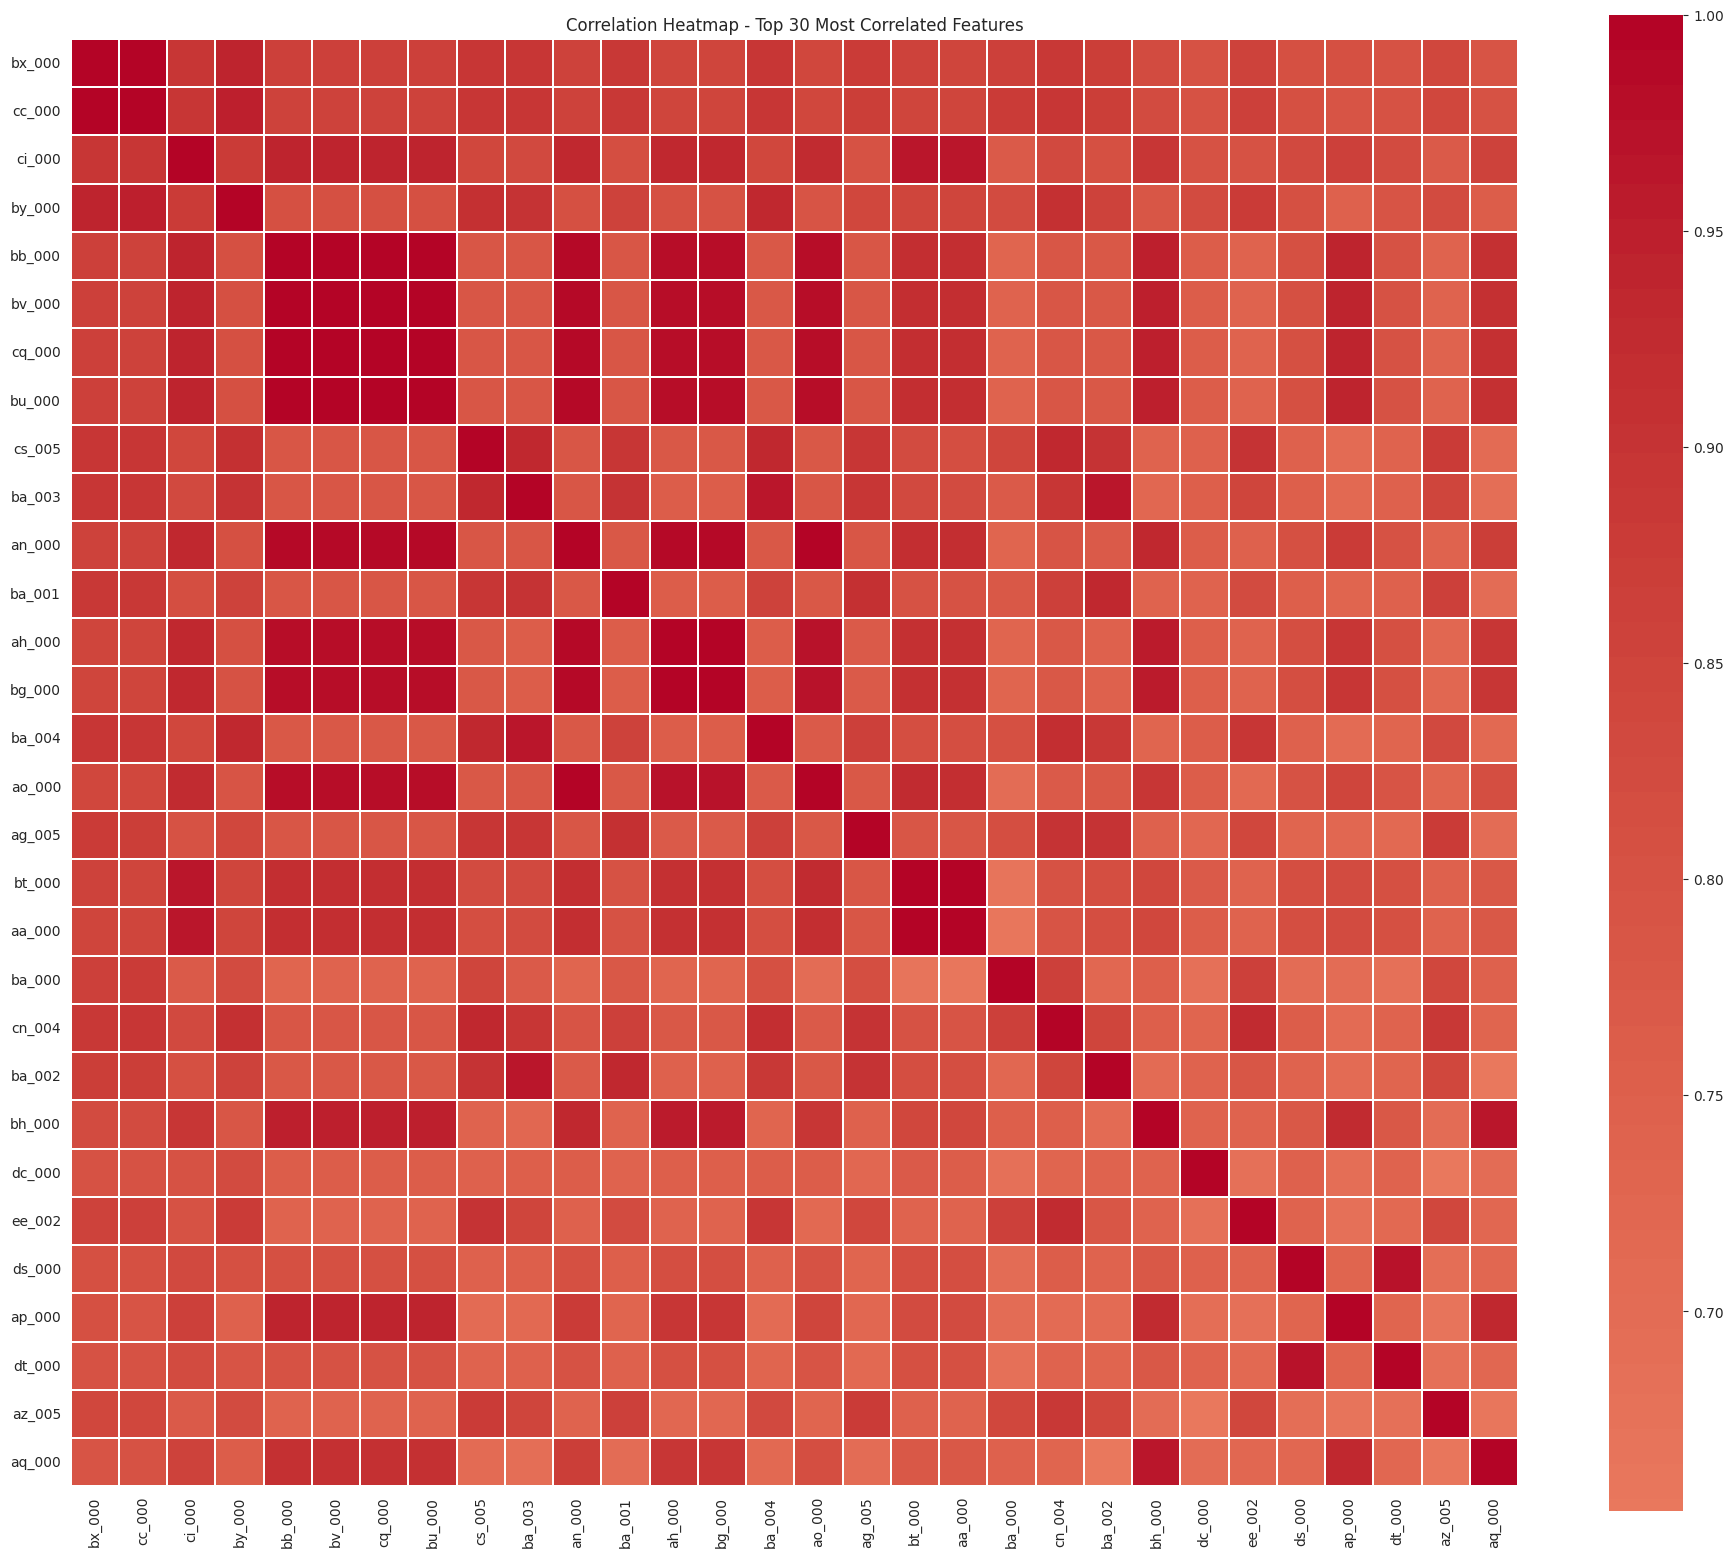

In [25]:
# Correlation heatmap

numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()
 
if TOP_K is not None and TOP_K < len(numeric_df.columns):
    avg_abs_corr = corr_matrix.abs().mean().sort_values(ascending=False)
    plot_cols = avg_abs_corr.head(TOP_K).index
    heatmap_title = f"Correlation Heatmap - Top {TOP_K} Most Correlated Features"
else:
    plot_cols = numeric_df.columns
    heatmap_title = "Correlation Heatmap - All Numeric Features"
 
fig, ax = plt.subplots(figsize=(min(24, len(plot_cols) * 0.5 + 4), min(20, len(plot_cols) * 0.5 + 4)))
sns.heatmap(
    corr_matrix.loc[plot_cols, plot_cols],
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.3,
    cbar_kws={"shrink": 0.8},
    ax=ax
)
ax.set_title(heatmap_title)
plt.tight_layout()
plt.show()

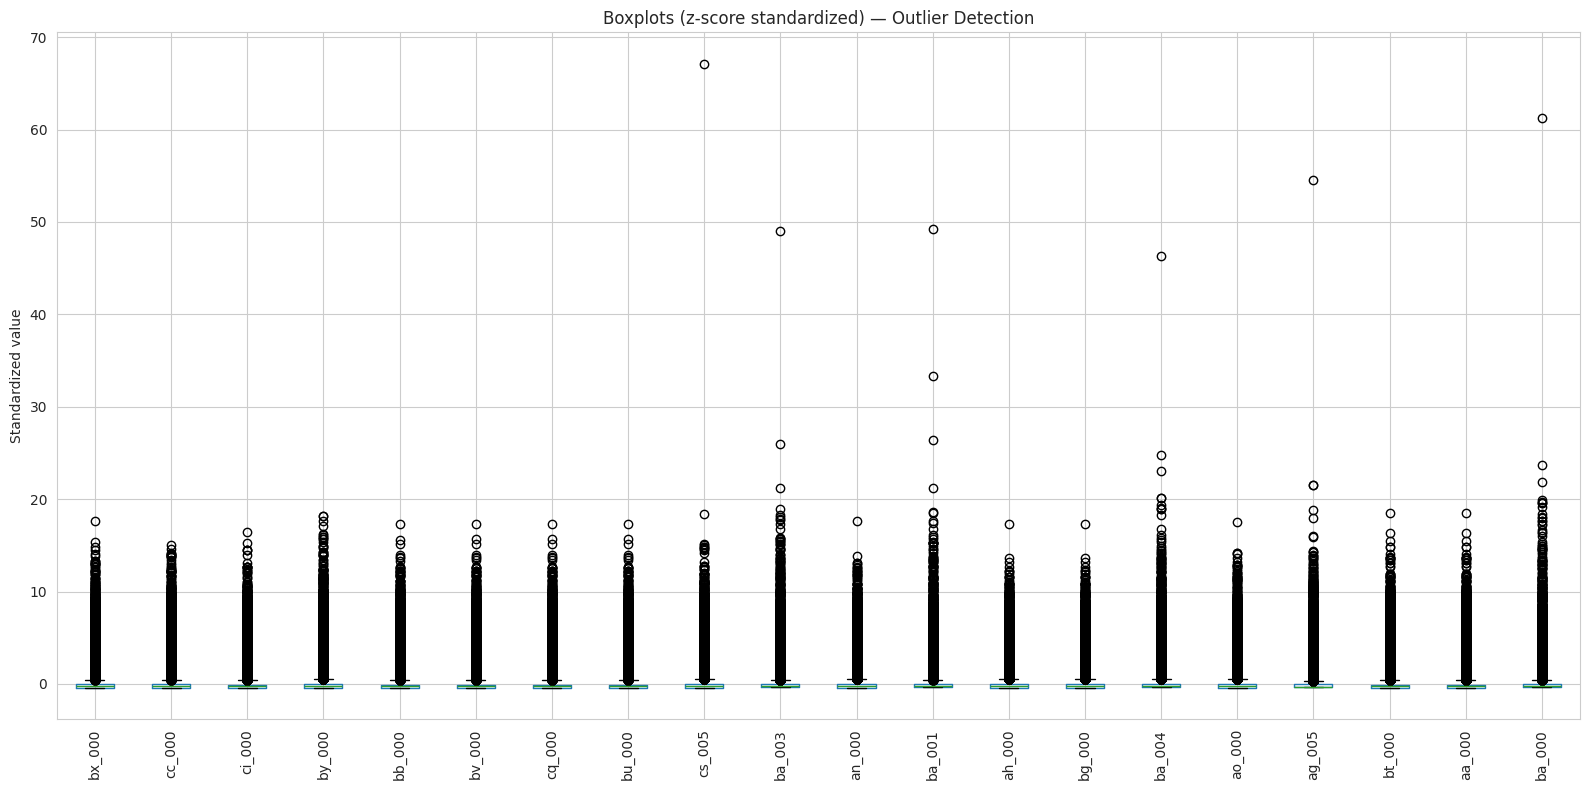

In [26]:
boxplot_cols = plot_cols[:20]  # cap at 20 for readability regardless of TOP_K
standardized = numeric_df[boxplot_cols].apply(zscore, nan_policy="omit")
 
fig, ax = plt.subplots(figsize=(16, 8))
standardized.boxplot(ax=ax, rot=90)
ax.set_title("Boxplots (z-score standardized) — Outlier Detection")
ax.set_ylabel("Standardized value")
plt.tight_layout()
plt.show()

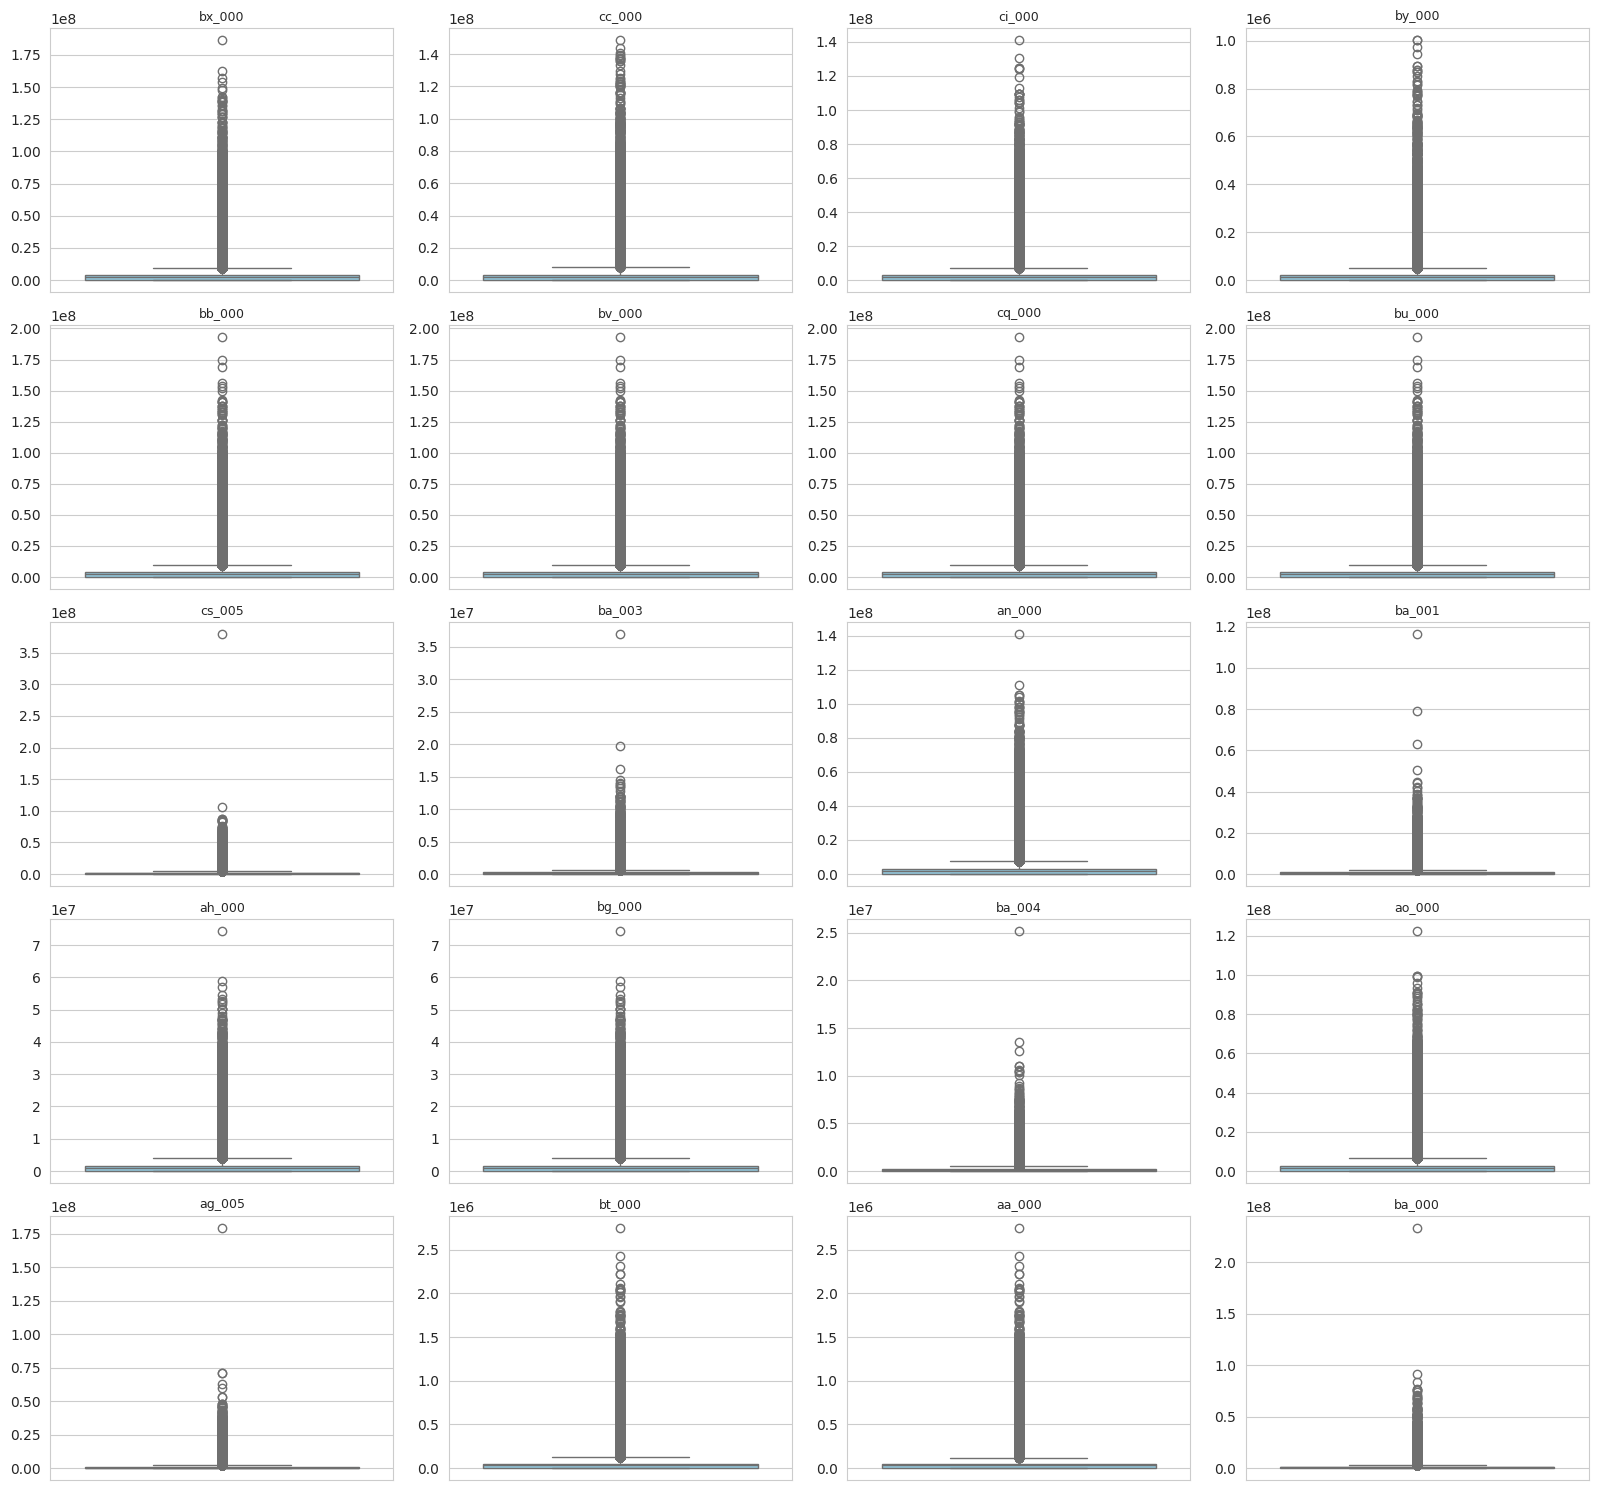

In [27]:
n_cols = 4
n_rows = int(np.ceil(len(boxplot_cols) / n_cols))
 
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3))
axes = axes.flatten()
 
for i, col in enumerate(boxplot_cols):
    sns.boxplot(y=numeric_df[col], ax=axes[i], color="skyblue")
    axes[i].set_title(col, fontsize=9)
    axes[i].set_ylabel("")
 
for j in range(len(boxplot_cols), len(axes)):
    axes[j].axis("off")
 
plt.tight_layout()
plt.show()

In [28]:
def iqr_outlier_count(series: pd.Series) -> int:
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return int(((series < lower) | (series > upper)).sum())
 
outlier_counts = (
    numeric_df[boxplot_cols]
    .apply(iqr_outlier_count)
    .sort_values(ascending=False)
    .to_frame("n_outliers")
)
outlier_counts["pct_outliers"] = (outlier_counts["n_outliers"] / len(numeric_df) * 100).round(2)
outlier_counts

,n_outliers,pct_outliers
ag_005,5946,9.91
aa_000,5627,9.38
bt_000,5572,9.29
ao_000,5225,8.71
ci_000,5211,8.68
bb_000,5172,8.62
cq_000,5149,8.58
bv_000,5149,8.58
bu_000,5149,8.58
an_000,5068,8.45
